# Food-crisis early warning from bilingual news

**Candidate:** Babaniyi Olaniyi  
**Deliverable:** reproducible research notebook (code, report, and reflection)  
**Region:** Iraq, Jordan, Lebanon, Palestine, and Syria

## Executive answer

This notebook turns English and Arabic news into an **auditable location-level evidence index**. It does not claim to predict food insecurity from one month of unlabeled data. That distinction is central: an operational early-warning system needs time-indexed ground truth, strictly forward validation, and a decision threshold tied to intervention costs.

The implemented prototype:

1. repairs and validates the 167-factor taxonomy;
2. adds a transparent Arabic seed translation for every English risk factor;
3. finds phrase-level risk factors without substring leakage;
4. geotags articles against the supplied country/province/district taxonomy and retains the most specific unambiguous locations;
5. deduplicates articles and normalizes for document length and news volume;
6. partially pools sparse locations with a beta-binomial empirical-Bayes estimate;
7. reports signal strength and evidence confidence separately, with bilingual corroboration and article-level drill-down;
8. translates the resulting ranking into a verification queue rather than an automated intervention decision.

**Important input note.** The two news CSVs named in the assignment are not present in the supplied directory. To keep every cell executable and test the full pipeline, the notebook automatically uses a small, clearly labeled synthetic fixture when either CSV is missing. No substantive finding is drawn from that fixture. Drop both CSVs into `data/` and rerun all cells to produce the real analysis.

The design follows Mueller & Rauh's “hard problem” logic: rare onsets, history and text as complementary signals, honest out-of-time evaluation, and policy thresholds based on asymmetric errors. It also borrows the news-feature idea from Balashankar, Subramanian & Fraiberger while refusing to fit a supervised model without labels.

## 1. Research question and estimand

The operational question is not “Which articles mention hunger?” but:

> **Which subnational areas show unusually broad, intense, and independently corroborated precursor evidence, and where is the evidence strong enough to justify human verification?**

The unit of a future forecast should be **location × month**, the target should be a forward outcome such as `IPC/CH phase ≥ 3 in t+h`, and the forecast vintage must contain only information available by month `t`. With the current snapshot, the estimand is only a contemporaneous *news evidence index*. A high value may reflect true deterioration, better media coverage, repeated syndication, conflict reporting, or lexical ambiguity; it is therefore a lead for triangulation, not a probability or causal estimate.

### Why geospatial information adds value

Country averages hide localized shocks and dilute actionable signals. District/province tags enable targeting, aggregation to administrative levels, linkage to rainfall/vegetation/price/conflict data, and spatial spillover features. The cost is name ambiguity, unequal media coverage, and “aboutness” errors (where an article mentions a place without describing conditions there). The supplied taxonomy has names but no boundaries, so this notebook performs hierarchical tagging and aggregation—not a choropleth. Boundaries and adjacency would be added in production.

### Evidence hierarchy

`news mention → bilingual/cross-source corroboration → quantitative covariates → delayed IPC/CH outcome`

Each arrow adds stronger evidence. News is timely but noisy; official food-security classifications are closer to the outcome but delayed. The system should preserve both rather than train on its own pseudo-labels.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import pickle
import re
import unicodedata
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import beta as beta_dist, spearmanr

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="white", context="notebook")

# A restrained editorial visual system used consistently throughout the notebook.
VIZ_BG = "#F5F2EA"
VIZ_INK = "#20303C"
VIZ_MUTED = "#CBD2D7"
VIZ_MUTED_DARK = "#76838C"
VIZ_ACCENT = "#D1495B"
VIZ_BLUE = "#2F6B8A"
VIZ_GOLD = "#D89B2B"

plt.rcParams.update(
    {
        "figure.facecolor": VIZ_BG,
        "axes.facecolor": VIZ_BG,
        "axes.edgecolor": VIZ_BG,
        "axes.labelcolor": VIZ_INK,
        "text.color": VIZ_INK,
        "xtick.color": VIZ_MUTED_DARK,
        "ytick.color": VIZ_INK,
        "font.family": "DejaVu Sans",
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "figure.titlesize": 19,
    }
)


def polish_axis(ax, keep_bottom=True):
    """Remove chart junk while retaining a readable quantitative scale."""
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", which="both", length=0, labelsize=10)
    if not keep_bottom:
        ax.tick_params(axis="x", labelbottom=False)
    ax.set_facecolor(VIZ_BG)


def add_caption(fig, text):
    fig.text(0.06, 0.012, text, ha="left", va="bottom", fontsize=8.5, color=VIZ_MUTED_DARK)


def spread_label_positions(values, minimum_gap=4.0, low=1.0, high=99.0):
    """Small deterministic label-repulsion helper for direct line labels."""
    ordered = sorted(enumerate(values), key=lambda pair: pair[1])
    placed = []
    for _, value in ordered:
        placed.append(max(value, placed[-1] + minimum_gap if placed else low))
    if placed and placed[-1] > high:
        shift = placed[-1] - high
        placed = [value - shift for value in placed]
    if placed and placed[0] < low:
        shift = low - placed[0]
        placed = [value + shift for value in placed]
    result = [None] * len(values)
    for (original_index, _), placed_value in zip(ordered, placed):
        result[original_index] = placed_value
    return result

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Works when launched from the project root or from a notebooks/ subdirectory.
HERE = Path.cwd().resolve()
ROOT = HERE if (HERE / "data").exists() else HERE.parent
DATA = ROOT / "data"
FILES = {
    "news_en": DATA / "news-articles-eng.csv",
    "news_ar": DATA / "news-articles-ara.csv",
    "risk": DATA / "risk-factors.xlsx",
    "categories": DATA / "risk-factors-categories.xlsx",
    "locations_en": DATA / "id_english_location_name.pkl",
    "locations_ar": DATA / "id_arabic_location_name.pkl",
}

required_reference = ["risk", "categories", "locations_en", "locations_ar"]
missing_reference = [name for name in required_reference if not FILES[name].exists()]
if missing_reference:
    raise FileNotFoundError(f"Missing required reference files: {missing_reference}")

file_audit = pd.DataFrame(
    {
        "input": FILES.keys(),
        "path": [str(p.relative_to(ROOT)) for p in FILES.values()],
        "present": [p.exists() for p in FILES.values()],
        "size_kb": [round(p.stat().st_size / 1024, 1) if p.exists() else np.nan for p in FILES.values()],
    }
)
display(file_audit)

,input,path,present,size_kb
0,news_en,data/news-articles-eng.csv,False,NaN
1,news_ar,data/news-articles-ara.csv,False,NaN
2,risk,data/risk-factors.xlsx,True,21.8
3,categories,data/risk-factors-categories.xlsx,True,20.6
4,locations_en,data/id_english_location_name.pkl,True,11.1
5,locations_ar,data/id_arabic_location_name.pkl,True,20.2


## 2. Load, normalize, and validate the reference data

Normalization is deliberately conservative. English punctuation and the malformed escaped apostrophe are standardized; Arabic diacritics, tatweel, and common alef/ya variants are normalized. We retain phrase boundaries, so the unigram `rise` cannot match `surprise`. The category join is performed on normalized keys and asserted to be one-to-one.

In [2]:
ARABIC_DIACRITICS = re.compile(r"[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06ED]")


def normalize_english(value: object) -> str:
    text = unicodedata.normalize("NFKC", str(value)).lower()
    text = text.replace("\\", " ").replace("_", "-")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def normalize_arabic(value: object) -> str:
    text = unicodedata.normalize("NFKC", str(value))
    text = ARABIC_DIACRITICS.sub("", text).replace("ـ", "")
    text = re.sub("[إأآٱ]", "ا", text)
    text = text.replace("ى", "ي").replace("ؤ", "و").replace("ئ", "ي")
    text = re.sub(r"[^\u0600-\u06FF0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def canonical_factor(value: object) -> str:
    return normalize_english(value)


risk_raw = pd.read_excel(FILES["risk"])
categories_raw = pd.read_excel(FILES["categories"])

# Accept the actual column names and the names used in the written brief.
risk_en_col = next(c for c in risk_raw.columns if "english" in c.lower())
risk_ar_col = next(c for c in risk_raw.columns if "arabic" in c.lower())
category_factor_col = next(c for c in categories_raw.columns if "factor" in c.lower())
category_col = next(c for c in categories_raw.columns if "cluster" in c.lower() or "category" in c.lower())

risk = risk_raw[[risk_en_col, risk_ar_col]].rename(
    columns={risk_en_col: "risk_factor_english", risk_ar_col: "risk_factor_arabic_original"}
)
categories = categories_raw[[category_factor_col, category_col]].rename(
    columns={category_factor_col: "risk_factor_category_file", category_col: "cluster"}
)
risk["factor_key"] = risk["risk_factor_english"].map(canonical_factor)
categories["factor_key"] = categories["risk_factor_category_file"].map(canonical_factor)

assert len(risk) == 167, f"Expected 167 risk factors; found {len(risk)}"
assert risk["factor_key"].is_unique, "Risk factors are not unique after normalization"
assert categories["factor_key"].is_unique, "Category keys are not unique after normalization"

lexicon = risk.merge(categories[["factor_key", "cluster"]], on="factor_key", how="left", validate="one_to_one")
assert lexicon["cluster"].notna().all(), "At least one normalized risk factor did not map to a cluster"

raw_join_missing = risk_raw[risk_en_col].isin(categories_raw[category_factor_col]).sum()
repair = pd.DataFrame(
    {
        "check": ["risk factors", "raw exact category matches", "normalized category matches", "clusters"],
        "value": [len(lexicon), raw_join_missing, lexicon["cluster"].notna().sum(), lexicon["cluster"].nunique()],
    }
)
display(repair)
display(lexicon.groupby("cluster").size().sort_values(ascending=False).rename("n_factors").to_frame())

,check,value
0,risk factors,167
1,raw exact category matches,166
2,normalized category matches,167
3,clusters,12


,n_factors
cluster,
conflicts and violence,35
political instability,19
economic issues,16
humanitarian aid,16
agricultural production issues,15
weather shocks,14
food crisis,13
land-related issues,10
other,9


### Arabic seed lexicon

The source Arabic column is 100% missing. Quietly machine-translating it at runtime would make results non-reproducible and can erase local usage. Instead, the prototype contains a deterministic Arabic translation for each factor. These are **seed terms**, not a claim of linguistic completeness. A production workflow would have two native Arabic reviewers independently assess each term, add dialectal/Mashriqi variants, adjudicate disagreements, and version the lexicon. Retrieval samples—not just aggregate counts—should be reviewed for precision.

In [3]:
# Pipe-delimited and versionable: English factor | Arabic seed phrase.
_ARABIC_SEEDS = r'''
massive starvation|مجاعة جماعية
rinderpest|طاعون البقر
scanty rainfall|شح الامطار
dysfunction|اختلال وظيفي
rise|ارتفاع
price rise|ارتفاع الاسعار
cattle plague|طاعون الماشية
mismanagement|سوء الادارة
harvest decline|تراجع المحصول
forests destroyed|تدمير الغابات
jihadist groups|جماعات جهادية
migration|الهجرة
stolen food aid|سرقة المساعدات الغذائية
economic impoverishment|افقار اقتصادي
asylum seekers|طالبو اللجوء
continued strife|صراع مستمر
ecological crisis|ازمة بيئية
climatic hazards|مخاطر مناخية
displaced|نازحون
food assistance|مساعدات غذائية
slave trade|تجارة الرقيق
gangs of bandits|عصابات قطاع الطرق
self reliance|الاعتماد علي الذات
devastated the economy|دمر الاقتصاد
land degradation|تدهور الاراضي
clan battle|معركة عشائرية
major offensive|هجوم واسع
farmland|اراض زراعية
restricted relief flights|تقييد رحلات الاغاثة
international embargo|حظر دولي
poor soil quality|تدني جودة التربة
blockade|حصار مفروض
years of warfare|سنوات من الحرب
foreign aid|مساعدات خارجية
internal strife|صراع داخلي
increased external debt|ارتفاع الدين الخارجي
humanitarian situation|الوضع الانساني
clans|عشائر
clan warfare|حرب عشائرية
air attack|هجوم جوي
rising food prices|ارتفاع اسعار الغذاء
international terrorists|ارهابيون دوليون
economic crisis|ازمة اقتصادية
convoys|قوافل
disrupted trade|تعطل التجارة
conflict|نزاع
floods|فيضانات
looting|نهب
rebel insurgency|تمرد مسلح
foreign troops|قوات اجنبية
reduced national output|انخفاض الناتج الوطني
brain drain|هجرة العقول
militia groups|جماعات مسلحة
destructive pattern|نمط مدمر
shortage of rains|نقص الامطار
rival warlords|امراء حرب متنافسون
violent suppression|قمع عنيف
the offensive|الهجوم العسكري
repression|قمع
police torture|تعذيب الشرطة
civil strife|اقتتال اهلي
warlord|امير حرب
human rights abuses|انتهاكات حقوق الانسان
mayhem|فوضي عارمة
terrorism|ارهاب
prolonged fighting|قتال مطول
terrorist|ارهابي
pirates|قراصنة
siege|حصار عسكري
brutal government|حكومة وحشية
bombing campaign|حملة قصف
rising inflation|ارتفاع التضخم
cycle of poverty|دائرة الفقر
reduced imports|انخفاض الواردات
price of food|سعر الغذاء
collapsing economy|انهيار الاقتصاد
slashed export|خفض الصادرات
carbon|كربون
climate change|تغير المناخ
greenhouse gases|غازات الدفيئة
environmental degradation|تدهور بيئي
natural disaster|كارثة طبيعية
gastrointestinal|امراض الجهاز الهضمي
hunger crises|ازمات جوع
apathy|خمول
malnourished|سوء التغذية
mass hunger|جوع جماعي
life threatening hunger|جوع يهدد الحياة
food insecurity|انعدام الامن الغذائي
infant mortality|وفيات الرضع
dehydrated|جفاف الجسم
food crisis|ازمة غذائية
acute hunger|جوع حاد
civilians uprooted|اقتلاع المدنيين
flee|يفرون
makeshift camps|مخيمات موقتة
refugees|لاجئون
humanitarian disaster|كارثة انسانية
withheld relief|حجب الاغاثة
international alarm|قلق دولي
call for donations|دعوة للتبرعات
without international aid|من دون مساعدات دولية
aid workers died|مقتل عمال اغاثة
restricted humanitarian access|تقييد وصول المساعدات الانسانية
international intervention|تدخل دولي
aid appeal|نداء اغاثة
pushing peasants off|طرد الفلاحين
land invasions|اجتياح الاراضي
burning houses|حرق المنازل
land reform|اصلاح الاراضي
land seizures|الاستيلاء علي الاراضي
land grab|اغتصاب الاراضي
tragedy|ماساة
man made disaster|كارثة من صنع الانسان
continued deterioration|تدهور مستمر
lack of alternatives|غياب البدائل
catastrophe|كارثة
wreaked havoc|احدث دمارا
alarming level|مستوي مقلق
population crisis|ازمة سكانية
pests|افات زراعية
cholera outbreak|تفشي الكوليرا
epidemics|اوبئة
potato blight|لفحة البطاطا
locusts|جراد
corruption|فساد
regimes were toppled|اسقاط الانظمة
corrupt government|حكومة فاسدة
military dictatorship|ديكتاتورية عسكرية
totalitarian|شمولي
collapse of government|انهيار الحكومة
oppressive regimes|انظمة قمعية
power struggle|صراع علي السلطة
military junta|مجلس عسكري
overthrow|اطاحة
dictators|طغاة
anti western policies|سياسات معادية للغرب
lack of authority|غياب السلطة
secession|انفصال
politically engineered|مدبر سياسيا
coup|انقلاب
authoritarian|استبدادي
prolonged dry spell|فترة جفاف طويلة
lack of rains|غياب الامطار
cyclone|اعصار
severe rains|امطار غزيرة
inadequate rainfall|عدم كفاية الامطار
drought|جفاف
water availability|توافر المياه
abnormally low rainfall|انخفاض غير طبيعي للامطار
failed rains|فشل موسم الامطار
weather extremes|ظواهر جوية متطرفة
lack of agricultural infrastructure|نقص البنية التحتية الزراعية
water distribution shortages|نقص توزيع المياه
bad harvests|محاصيل سيئة
infrastructure damage|اضرار البنية التحتية
lack of cultivation|نقص الزراعة
lack of roads|نقص الطرق
unable to sow|عدم القدرة علي البذر
harvests are devastated|تدمر المحاصيل
failed crops|فشل المحاصيل
toll on livestock|خساير الماشية
disruption to farming|تعطل الزراعة
livestock had died|نفوق الماشية
cattle death|نفوق الابقار
transport bottleneck|اختناق النقل
d etat|انقلاب عسكري
'''.strip()

arabic_seed_map = {}
for line in _ARABIC_SEEDS.splitlines():
    english, arabic = line.split("|", 1)
    arabic_seed_map[canonical_factor(english)] = arabic.strip()

lexicon["risk_factor_arabic"] = lexicon["factor_key"].map(arabic_seed_map)
missing_arabic = lexicon.loc[lexicon["risk_factor_arabic"].isna(), "risk_factor_english"].tolist()
extra_arabic = sorted(set(arabic_seed_map) - set(lexicon["factor_key"]))
assert not missing_arabic, f"Arabic seeds missing for: {missing_arabic}"
assert not extra_arabic, f"Arabic seeds have unknown factors: {extra_arabic}"
assert lexicon["risk_factor_arabic"].map(normalize_arabic).ne("").all()

translation_audit = pd.DataFrame(
    {
        "metric": ["source Arabic cells filled", "prototype Arabic seeds filled", "unique normalized Arabic phrases"],
        "value": [risk[risk_ar_col if risk_ar_col in risk.columns else "risk_factor_arabic_original"].notna().sum()
                  if risk_ar_col in risk.columns else risk["risk_factor_arabic_original"].notna().sum(),
                  lexicon["risk_factor_arabic"].notna().sum(),
                  lexicon["risk_factor_arabic"].map(normalize_arabic).nunique()],
    }
)
display(translation_audit)
display(lexicon[["risk_factor_english", "risk_factor_arabic", "cluster"]].sample(10, random_state=RANDOM_SEED))

,metric,value
0,source Arabic cells filled,0
1,prototype Arabic seeds filled,167
2,unique normalized Arabic phrases,167


,risk_factor_english,risk_factor_arabic,cluster
101,call for donations,دعوة للتبرعات,humanitarian aid
108,failed crops,فشل المحاصيل,agricultural production issues
78,humanitarian disaster,كارثة انسانية,humanitarian aid
56,totalitarian,شمولي,political instability
98,food crisis,ازمة غذائية,food crisis
29,blockade,حصار مفروض,conflicts and violence
105,without international aid,من دون مساعدات دولية,humanitarian aid
82,rebel insurgency,تمرد مسلح,conflicts and violence
104,land invasions,اجتياح الاراضي,land-related issues
109,severe rains,امطار غزيرة,weather shocks


## 3. Geographic taxonomy and phrase-matching engine

Location keys encode hierarchy: `country`, `country_province`, and `country_province_district`. Articles can mention more than one place; the matcher retains all most-specific, unambiguous matches. If a district is identified, the country/province can always be recovered from its key. Ambiguous aliases are excluded unless a country mention disambiguates them. This is preferable to silently assigning a common place name to the wrong district.

In [4]:
with open(FILES["locations_en"], "rb") as fh:
    locations_en = pickle.load(fh)
with open(FILES["locations_ar"], "rb") as fh:
    locations_ar = pickle.load(fh)


def geo_level(geo_id: str) -> str:
    return {0: "country", 1: "province", 2: "district"}.get(geo_id.count("_"), "other")


def parent_id(geo_id: str) -> str | None:
    parts = geo_id.split("_")
    return "_".join(parts[:-1]) if len(parts) > 1 else None


def first_alias(mapping: dict, geo_id: str) -> str:
    values = list(mapping.get(geo_id, []))
    return str(values[0]) if values else geo_id


geo_rows = []
for geo_id in sorted(set(locations_en) | set(locations_ar)):
    geo_rows.append(
        {
            "geo_id": geo_id,
            "level": geo_level(geo_id),
            "parent_id": parent_id(geo_id),
            "country_id": geo_id[:2],
            "name_en": first_alias(locations_en, geo_id).title(),
            "name_ar": first_alias(locations_ar, geo_id),
            "aliases_en": list(locations_en.get(geo_id, [])),
            "aliases_ar": list(locations_ar.get(geo_id, [])),
        }
    )
geo = pd.DataFrame(geo_rows).set_index("geo_id", drop=False)


def make_phrase_lookup(rows, key_col, value_col, normalizer):
    lookup = defaultdict(set)
    for _, row in rows.iterrows():
        phrase = normalizer(row[key_col])
        if phrase:
            lookup[phrase].add(row[value_col])
    return dict(lookup)


def make_location_lookup(mapping: dict, normalizer):
    lookup = defaultdict(set)
    for geo_id, aliases in mapping.items():
        for alias in list(aliases):
            phrase = normalizer(alias)
            if phrase:
                lookup[phrase].add(geo_id)
    return dict(lookup)


def scan_phrases(text: object, lookup: dict[str, set], normalizer) -> tuple[Counter, dict]:
    # Exact token n-gram matching; return value counts and matched surface phrases.
    normalized = normalizer(text)
    tokens = normalized.split()
    lengths = sorted({len(k.split()) for k in lookup}, reverse=True)
    counts = Counter()
    evidence = defaultdict(list)
    occupied = set()
    for n in lengths:
        if n > len(tokens):
            continue
        for i in range(len(tokens) - n + 1):
            span = set(range(i, i + n))
            if occupied.intersection(span):
                continue
            phrase = " ".join(tokens[i : i + n])
            if phrase in lookup:
                for value in lookup[phrase]:
                    counts[value] += 1
                    evidence[value].append(phrase)
                # Prefer the longest match at an overlapping token span. This prevents
                # “price rise” from also being counted as the unigram “rise”.
                occupied.update(span)
    return counts, dict(evidence)


risk_lookup_en = make_phrase_lookup(lexicon, "risk_factor_english", "factor_key", normalize_english)
risk_lookup_ar = make_phrase_lookup(lexicon, "risk_factor_arabic", "factor_key", normalize_arabic)
location_lookup_en = make_location_lookup(locations_en, normalize_english)
location_lookup_ar = make_location_lookup(locations_ar, normalize_arabic)


def resolve_locations(text: object, language: str):
    lookup = location_lookup_ar if language == "ar" else location_lookup_en
    normalizer = normalize_arabic if language == "ar" else normalize_english
    tokens = normalizer(text).split()
    matched_phrases = set()
    for n in sorted({len(k.split()) for k in lookup}, reverse=True):
        matched_phrases.update(
            " ".join(tokens[i : i + n])
            for i in range(max(0, len(tokens) - n + 1))
            if " ".join(tokens[i : i + n]) in lookup
        )
    country_context = {
        g for phrase in matched_phrases for g in lookup[phrase] if geo_level(g) == "country"
    }
    candidates, ambiguous = set(), []
    for phrase in matched_phrases:
        ids = set(lookup[phrase])
        contextual = {g for g in ids if not country_context or g[:2] in country_context}
        ids = contextual or ids
        if len(ids) == 1:
            candidates.update(ids)
            continue

        # A name can validly label a province and a same-named district. Retain the
        # coarsest shared unit if the alternatives form one hierarchy; do not guess
        # between unrelated places that merely share a name.
        coarsest = min(ids, key=lambda g: g.count("_"))
        if all(g == coarsest or g.startswith(coarsest + "_") for g in ids):
            candidates.add(coarsest)
        else:
            ambiguous.append({"phrase": phrase, "candidate_ids": sorted(ids)})

    # Keep only deepest candidates along the same hierarchy; distinct locations survive.
    most_specific = set(candidates)
    for g in candidates:
        if any(other != g and other.startswith(g + "_") for other in candidates):
            most_specific.discard(g)
    return sorted(most_specific), ambiguous


# Unit checks target the two most damaging lexical failure modes.
assert not scan_phrases("A surprise result", risk_lookup_en, normalize_english)[0].get("rise", 0)
assert scan_phrases("A price rise followed drought", risk_lookup_en, normalize_english)[0]["price rise"] == 1
assert normalize_arabic("إِنْعِدَامُ الأَمْنِ الغِذَائِيّ") == normalize_arabic("انعدام الامن الغذائي")

geo_audit = geo.groupby("level").size().rename("locations").to_frame()
geo_audit["english_aliases"] = geo.groupby("level")["aliases_en"].apply(lambda s: sum(map(len, s)))
geo_audit["arabic_aliases"] = geo.groupby("level")["aliases_ar"].apply(lambda s: sum(map(len, s)))
display(geo_audit)

,locations,english_aliases,arabic_aliases
level,,,
country,5,9,8
district,298,500,331
province,54,98,61


## 4. News ingestion and data contract

The loader tolerates common column-name variants, combines title and body, parses dates, and creates stable article IDs. If neither a known body column nor a title exists, it chooses the object column with the longest median text—a pragmatic fallback that is reported in the schema audit. Deduplication happens within language on normalized full text; this removes exact syndication but not lightly edited copies (a production pipeline should add MinHash/semantic near-duplicate detection).

Because the requested news files are absent here, a deterministic fixture exercises multilingual matching, deduplication, geotagging, sparsity, and null articles. Its rows are visibly labeled `synthetic_*`, and all downstream headings display the active mode.

In [5]:
def synthetic_fixture() -> tuple[pd.DataFrame, pd.DataFrame]:
    en = pd.DataFrame(
        [
            ("e01", "2025-01-03", "Drought and rising food prices in Baghdad", "Failed crops near Baghdad, Iraq, have caused rising food prices and food insecurity.", "synthetic_wire_a"),
            ("e02", "2025-01-05", "Aid access restricted in Aleppo", "Restricted humanitarian access and a transport bottleneck affect food assistance in Aleppo, Syria.", "synthetic_wire_b"),
            ("e03", "2025-01-07", "Heavy rain in Jordan", "Severe rains were reported in Amman, Jordan, but officials reported no food crisis.", "synthetic_wire_a"),
            ("e04", "2025-01-08", "Markets in Beirut", "Rising inflation and the price of food are worsening the economic crisis in Beirut, Lebanon.", "synthetic_wire_c"),
            ("e05", "2025-01-10", "Displacement in Gaza", "Displaced civilians in Gaza, Palestine, face acute hunger after a blockade and bombing campaign.", "synthetic_wire_b"),
            ("e06", "2025-01-12", "Locust warning", "Locusts and inadequate rainfall may disrupt farming around Mosul, Iraq.", "synthetic_wire_a"),
            ("e07", "2025-01-13", "Trade forum", "A regional trade forum opened in Amman, Jordan.", "synthetic_wire_c"),
            ("e08", "2025-01-15", "Drought and rising food prices in Baghdad", "Failed crops near Baghdad, Iraq, have caused rising food prices and food insecurity.", "synthetic_wire_d"),
        ], columns=["id", "publication_date", "headline", "content", "source"]
    )
    ar = pd.DataFrame(
        [
            ("a01", "2025-01-04", "الجفاف يرفع اسعار الغذاء في بغداد", "فشل المحاصيل في بغداد العراق سبب ارتفاع اسعار الغذاء وانعدام الامن الغذائي.", "synthetic_ar_a"),
            ("a02", "2025-01-06", "تقييد الاغاثة في حلب", "تقييد وصول المساعدات الانسانية وتعطل الزراعة يهددان المساعدات الغذائية في حلب سوريا.", "synthetic_ar_b"),
            ("a03", "2025-01-09", "ازمة اقتصادية في بيروت", "ارتفاع التضخم وسعر الغذاء يعمقان الازمة الاقتصادية في بيروت لبنان.", "synthetic_ar_c"),
            ("a04", "2025-01-11", "جوع حاد بين النازحين في غزة", "نازحون في غزة فلسطين يواجهون جوعا حادا بعد حصار عسكري وحملة قصف.", "synthetic_ar_b"),
            ("a05", "2025-01-14", "الطقس في عمان", "توافرت المياه في عمان الاردن ولم تسجل ازمة غذائية.", "synthetic_ar_a"),
            ("a06", "2025-01-16", "خبر بلا موقع", "كارثة طبيعية سببت نزوح السكان ونقص الطرق.", "synthetic_ar_d"),
        ], columns=["id", "publication_date", "headline", "content", "source"]
    )
    return en, ar


def read_csv_robust(path: Path) -> pd.DataFrame:
    errors = []
    for encoding in ("utf-8", "utf-8-sig", "cp1256", "latin-1"):
        try:
            return pd.read_csv(path, encoding=encoding, low_memory=False)
        except UnicodeDecodeError as exc:
            errors.append(f"{encoding}: {exc}")
    raise UnicodeError("Could not decode file. " + " | ".join(errors))


def normalized_column_map(columns):
    return {normalize_english(c).replace(" ", "_"): c for c in columns}


def select_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    mapping = normalized_column_map(df.columns)
    for candidate in candidates:
        key = normalize_english(candidate).replace(" ", "_")
        if key in mapping:
            return mapping[key]
    return None


def standardize_news(df: pd.DataFrame, language: str) -> tuple[pd.DataFrame, dict]:
    df = df.copy()
    title_col = select_column(df, ["headline", "title", "article_title", "name"])
    body_col = select_column(df, ["content", "body", "text", "article_text", "full_text", "description", "article"])
    date_col = select_column(df, ["publication_date", "published_at", "publish_date", "date", "datetime", "timestamp"])
    id_col = select_column(df, ["article_id", "id", "document_id", "uuid"])
    source_col = select_column(df, ["source", "publication", "publisher", "outlet"])

    object_cols = [c for c in df.columns if df[c].dtype == "object"]
    if body_col is None and object_cols:
        median_lengths = {c: df[c].fillna("").astype(str).str.len().median() for c in object_cols}
        body_col = max(median_lengths, key=median_lengths.get)
    if body_col is None and title_col is None:
        raise ValueError(f"No usable text column found in {language} news file")

    title = df[title_col].fillna("").astype(str) if title_col else pd.Series("", index=df.index)
    body = df[body_col].fillna("").astype(str) if body_col else pd.Series("", index=df.index)
    text = (title.str.strip() + ". " + body.str.strip()).str.strip(". ")
    normalizer = normalize_arabic if language == "ar" else normalize_english
    text_norm = text.map(normalizer)
    generated_id = [hashlib.sha1(f"{language}|{x}".encode("utf-8")).hexdigest()[:16] for x in text_norm]

    out = pd.DataFrame(
        {
            "article_id": df[id_col].astype(str).values if id_col else generated_id,
            "language": language,
            "date": pd.to_datetime(df[date_col], errors="coerce", utc=True).dt.tz_localize(None) if date_col else pd.NaT,
            "source": df[source_col].fillna("unknown").astype(str).values if source_col else "unknown",
            "title": title.values,
            "text": text.values,
            "text_norm": text_norm.values,
        }
    )
    out = out[out["text_norm"].ne("")].copy()
    schema = {
        "language": language,
        "input_rows": len(df),
        "output_nonempty_rows": len(out),
        "title_column": title_col,
        "body_column": body_col,
        "date_column": date_col,
        "id_column": id_col,
        "source_column": source_col,
        "unparseable_dates": int(out["date"].isna().sum()),
    }
    return out, schema


news_present = FILES["news_en"].exists() and FILES["news_ar"].exists()
if news_present:
    raw_en, raw_ar = read_csv_robust(FILES["news_en"]), read_csv_robust(FILES["news_ar"])
    DATA_MODE = "PROVIDED NEWS DATA"
else:
    raw_en, raw_ar = synthetic_fixture()
    DATA_MODE = "SYNTHETIC PIPELINE FIXTURE — NOT EMPIRICAL EVIDENCE"

news_en, schema_en = standardize_news(raw_en, "en")
news_ar, schema_ar = standardize_news(raw_ar, "ar")
news_before = pd.concat([news_en, news_ar], ignore_index=True)
news_before["content_hash"] = news_before.apply(
    lambda r: hashlib.sha1(f"{r.language}|{r.text_norm}".encode("utf-8")).hexdigest(), axis=1
)
news = news_before.sort_values(["language", "date", "article_id"]).drop_duplicates(
    ["language", "content_hash"], keep="first"
).reset_index(drop=True)

display(Markdown(f"### Active mode: **{DATA_MODE}**"))
display(pd.DataFrame([schema_en, schema_ar]))
display(pd.DataFrame({"metric": ["rows before exact deduplication", "rows after", "duplicates removed"],
                      "value": [len(news_before), len(news), len(news_before) - len(news)]}))

### Active mode: **SYNTHETIC PIPELINE FIXTURE — NOT EMPIRICAL EVIDENCE**

,language,input_rows,output_nonempty_rows,title_column,body_column,date_column,id_column,source_column,unparseable_dates
0,en,8,8,headline,content,publication_date,id,source,0
1,ar,6,6,headline,content,publication_date,id,source,0


,metric,value
0,rows before exact deduplication,14
1,rows after,13
2,duplicates removed,1


## 5. Article-level feature extraction

For each article the pipeline records factor identities, thematic clusters, mention counts, token count, resolved geographies, ambiguous location aliases, and a short audit snippet. Counts are retained for intensity, but each factor/cluster is counted at most once per article for breadth. This prevents a long or repetitive article from dominating the alert.

Negation is a known limitation: a phrase such as “no food crisis” is still retrieved. That choice favors recall in the first-stage screen; a human review queue or a validated multilingual contextual classifier should handle assertion, negation, and affected-population roles later.

In [6]:
factor_to_cluster = lexicon.set_index("factor_key")["cluster"].to_dict()
factor_to_display = lexicon.set_index("factor_key")["risk_factor_english"].to_dict()


def extract_article(row: pd.Series) -> pd.Series:
    language = row["language"]
    risk_lookup = risk_lookup_ar if language == "ar" else risk_lookup_en
    normalizer = normalize_arabic if language == "ar" else normalize_english
    risk_counts, risk_evidence = scan_phrases(row["text"], risk_lookup, normalizer)
    geo_ids, ambiguous = resolve_locations(row["text"], language)
    factors = sorted(risk_counts)
    cluster_counts = Counter()
    for factor, count in risk_counts.items():
        cluster_counts[factor_to_cluster[factor]] += count
    tokens = normalizer(row["text"]).split()
    return pd.Series(
        {
            "token_count": len(tokens),
            "risk_mention_count": int(sum(risk_counts.values())),
            "risk_factor_count": len(factors),
            "cluster_count": len(cluster_counts),
            "risk_factors": factors,
            "risk_factor_labels": [factor_to_display[f] for f in factors],
            "risk_evidence": risk_evidence,
            "cluster_mentions": dict(cluster_counts),
            "clusters": sorted(cluster_counts),
            "geo_ids": geo_ids,
            "ambiguous_locations": ambiguous,
            "has_risk": bool(factors),
            "has_geo": bool(geo_ids),
        }
    )


features = news.apply(extract_article, axis=1)
articles = pd.concat([news, features], axis=1)
articles["month"] = articles["date"].dt.to_period("M").astype("string")
articles["snippet"] = articles["text"].str.replace(r"\s+", " ", regex=True).str.slice(0, 180)

coverage = pd.DataFrame(
    {
        "metric": ["articles", "with a risk phrase", "with an unambiguous location", "with both", "ambiguous location mentions"],
        "value": [len(articles), int(articles.has_risk.sum()), int(articles.has_geo.sum()),
                  int((articles.has_risk & articles.has_geo).sum()),
                  int(articles.ambiguous_locations.map(bool).sum())],
    }
)
coverage["share"] = coverage["value"] / max(len(articles), 1)
display(coverage)

article_audit = articles.loc[
    articles.has_risk | articles.has_geo,
    ["article_id", "language", "date", "source", "risk_factor_labels", "clusters", "geo_ids", "snippet"],
].head(12)
display(article_audit)

,metric,value,share
0,articles,13,1.000000
1,with a risk phrase,12,0.923077
2,with an unambiguous location,12,0.923077
3,with both,11,0.846154
4,ambiguous location mentions,0,0.000000


,article_id,language,date,source,risk_factor_labels,clusters,geo_ids,snippet
0,a01,ar,2025-01-04,synthetic_ar_a,"[failed crops, rising food prices]","[agricultural production issues, economic issues]",[iq_bg],الجفاف يرفع اسعار الغذاء في بغداد. فشل المحاصيل في بغداد العراق سبب ارتفاع اسعار الغذا...
1,a02,ar,2025-01-06,synthetic_ar_b,[restricted humanitarian access],[humanitarian aid],[sy_hl],تقييد الاغاثة في حلب. تقييد وصول المساعدات الانسانية وتعطل الزراعة يهددان المساعدات ال...
2,a03,ar,2025-01-09,synthetic_ar_c,"[economic crisis, rising inflation]",[economic issues],[lb_ba],ازمة اقتصادية في بيروت. ارتفاع التضخم وسعر الغذاء يعمقان الازمة الاقتصادية في بيروت لبنان
3,a04,ar,2025-01-11,synthetic_ar_b,"[acute hunger, displaced, siege]","[conflicts and violence, food crisis, forced displacement]",[ps_gz],جوع حاد بين النازحين في غزة. نازحون في غزة فلسطين يواجهون جوعا حادا بعد حصار عسكري وحم...
4,a05,ar,2025-01-14,synthetic_ar_a,[food crisis],[food crisis],[jo_am],الطقس في عمان. توافرت المياه في عمان الاردن ولم تسجل ازمة غذائية
5,a06,ar,2025-01-16,synthetic_ar_d,[natural disaster],[environmental issues],[],خبر بلا موقع. كارثة طبيعية سببت نزوح السكان ونقص الطرق
6,e01,en,2025-01-03,synthetic_wire_a,"[drought, failed crops, food insecurity, rising food prices]","[agricultural production issues, economic issues, food crisis, weather shocks]",[iq_bg],"Drought and rising food prices in Baghdad. Failed crops near Baghdad, Iraq, have cause..."
7,e02,en,2025-01-05,synthetic_wire_b,"[food assistance, restricted humanitarian access, transport bottleneck]","[agricultural production issues, humanitarian aid]",[sy_hl],Aid access restricted in Aleppo. Restricted humanitarian access and a transport bottle...
8,e03,en,2025-01-07,synthetic_wire_a,"[food crisis, severe rains]","[food crisis, weather shocks]",[jo_am],"Heavy rain in Jordan. Severe rains were reported in Amman, Jordan, but officials repor..."
9,e04,en,2025-01-08,synthetic_wire_c,"[economic crisis, price of food, rising inflation]",[economic issues],[lb_ba],Markets in Beirut. Rising inflation and the price of food are worsening the economic c...


## 6. Descriptive retrieval diagnostics

These figures diagnose what the lexicon retrieves; they are not outcome validation. In a real run, reviewers should inspect random true/false candidate samples stratified by language, cluster, and source, then estimate precision with confidence intervals. Recall requires a separately annotated sample that was not constructed from the same keywords.

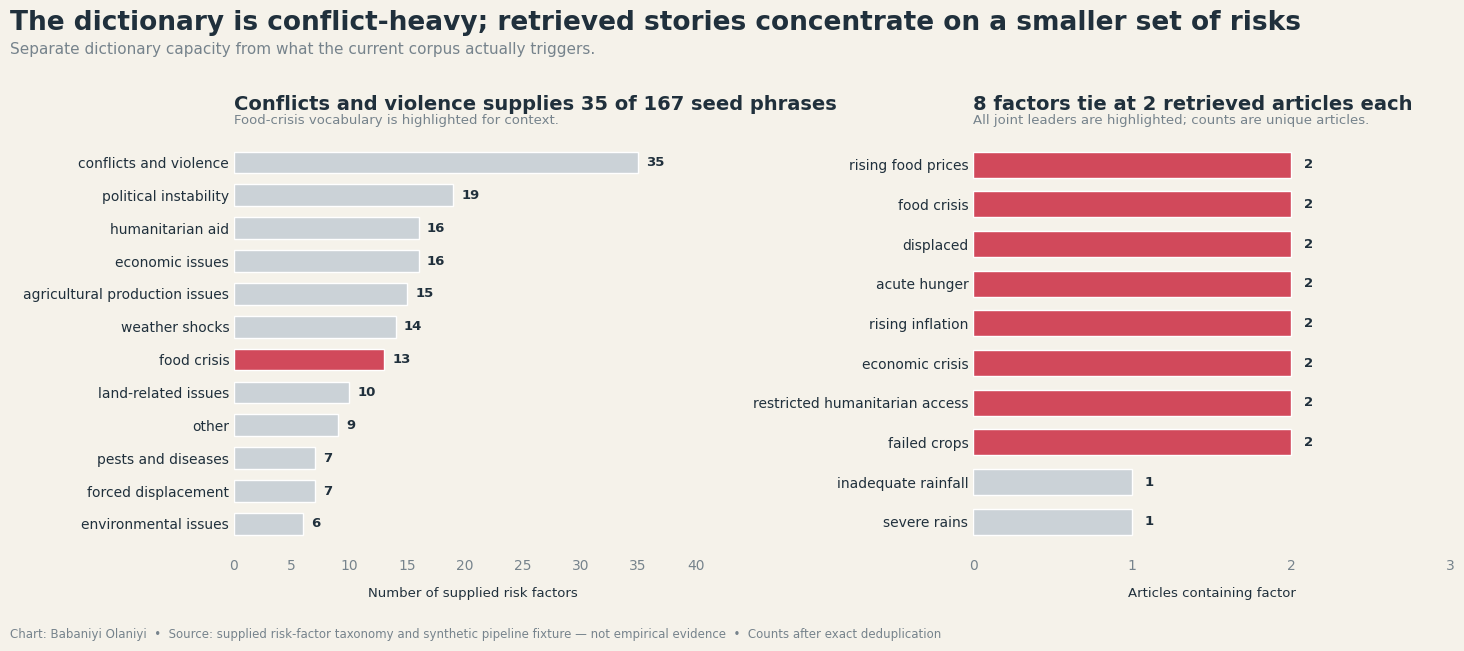

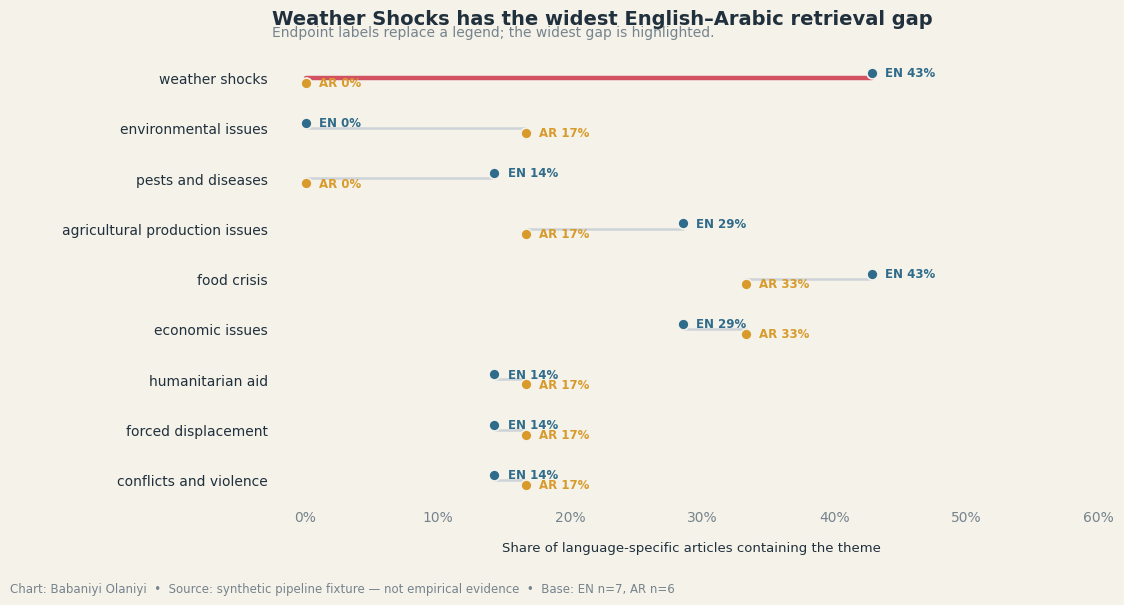

,language,cluster,hits,n_articles,articles_per_100
0,ar,agricultural production issues,1,6,16.666667
7,en,agricultural production issues,2,7,28.571429
1,ar,conflicts and violence,1,6,16.666667
8,en,conflicts and violence,1,7,14.285714
2,ar,economic issues,2,6,33.333333
9,en,economic issues,2,7,28.571429
3,ar,environmental issues,1,6,16.666667
4,ar,food crisis,2,6,33.333333
10,en,food crisis,3,7,42.857143
5,ar,forced displacement,1,6,16.666667


In [7]:

factor_rows, cluster_rows = [], []
for _, row in articles.iterrows():
    for factor in row["risk_factors"]:
        factor_rows.append({"article_id": row.article_id, "language": row.language,
                            "factor": factor_to_display[factor], "cluster": factor_to_cluster[factor]})
    for cluster in row["clusters"]:
        cluster_rows.append({"article_id": row.article_id, "language": row.language, "cluster": cluster})
factor_hits = pd.DataFrame(factor_rows, columns=["article_id", "language", "factor", "cluster"])
cluster_hits = pd.DataFrame(cluster_rows, columns=["article_id", "language", "cluster"])

# --- Figure 1: paired editorial bar charts ---------------------------------
cluster_sizes = lexicon.groupby("cluster").size().sort_values()
focus_cluster = "food crisis"
top_factor_counts = factor_hits["factor"].value_counts().head(10).sort_values() if not factor_hits.empty else pd.Series(dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.8), facecolor=VIZ_BG)
fig.subplots_adjust(left=0.20, right=0.96, top=0.76, bottom=0.14, wspace=0.55)
fig.suptitle(
    "The dictionary is conflict-heavy; retrieved stories concentrate on a smaller set of risks",
    x=0.06, y=0.94, ha="left", fontsize=19, fontweight="bold", color=VIZ_INK,
)
fig.text(
    0.06, 0.875,
    "Separate dictionary capacity from what the current corpus actually triggers.",
    ha="left", fontsize=11, color=VIZ_MUTED_DARK,
)

ax = axes[0]
bar_colors = [VIZ_ACCENT if name == focus_cluster else VIZ_MUTED for name in cluster_sizes.index]
bars = ax.barh(cluster_sizes.index, cluster_sizes.values, color=bar_colors, height=0.66)
for bar, value in zip(bars, cluster_sizes.values):
    ax.text(value + 0.7, bar.get_y() + bar.get_height() / 2, f"{value}", va="center",
            fontsize=9.5, fontweight="bold", color=VIZ_INK)
largest_name, largest_value = cluster_sizes.index[-1], int(cluster_sizes.iloc[-1])
ax.set_title(f"{largest_name.capitalize()} supplies {largest_value} of 167 seed phrases", loc="left", pad=16)
ax.text(0, 1.02, "Food-crisis vocabulary is highlighted for context.", transform=ax.transAxes,
        fontsize=9.5, color=VIZ_MUTED_DARK)
ax.set_xlim(0, cluster_sizes.max() * 1.18)
ax.set_xlabel("Number of supplied risk factors", labelpad=10, fontsize=9.5)
ax.set_ylabel("")
polish_axis(ax)

ax = axes[1]
if not top_factor_counts.empty:
    top_count = int(top_factor_counts.max())
    highlight_names = set(top_factor_counts[top_factor_counts.eq(top_count)].index)
    colors = [VIZ_ACCENT if name in highlight_names else VIZ_MUTED for name in top_factor_counts.index]
    bars = ax.barh(top_factor_counts.index, top_factor_counts.values, color=colors, height=0.66)
    for bar, value in zip(bars, top_factor_counts.values):
        ax.text(value + 0.08, bar.get_y() + bar.get_height() / 2, f"{int(value)}", va="center",
                fontsize=9.5, fontweight="bold", color=VIZ_INK)
    leaders = top_factor_counts[top_factor_counts.eq(top_count)].index.tolist()
    retrieval_title = (f'“{leaders[0].title()}” is the most widely retrieved phrase'
                       if len(leaders) == 1 else f"{len(leaders)} factors tie at {top_count} retrieved articles each")
    retrieval_subtitle = ("The leading factor is highlighted; counts are unique articles."
                          if len(leaders) == 1 else "All joint leaders are highlighted; counts are unique articles.")
    ax.set_title(retrieval_title, loc="left", pad=16)
    ax.text(0, 1.02, retrieval_subtitle, transform=ax.transAxes, fontsize=9.5, color=VIZ_MUTED_DARK)
    ax.set_xlim(0, max(top_factor_counts.max() * 1.28, 2))
    tick_step = max(1, math.ceil(float(top_factor_counts.max()) / 5))
    ax.set_xticks(np.arange(0, int(top_factor_counts.max()) + tick_step + 1, tick_step))
    ax.set_xlabel("Articles containing factor", labelpad=10, fontsize=9.5)
    ax.set_ylabel("")
    polish_axis(ax)
else:
    ax.text(0.5, 0.5, "No factor matches", ha="center", va="center", fontsize=14, color=VIZ_MUTED_DARK)
    ax.set_title("No phrases were retrieved", loc="left", pad=16)
    polish_axis(ax, keep_bottom=False)

add_caption(fig, f"Chart: Babaniyi Olaniyi  •  Source: supplied risk-factor taxonomy and {DATA_MODE.lower()}  •  Counts after exact deduplication")
plt.show()

# --- Figure 2: direct-labeled bilingual dumbbell chart --------------------
if not cluster_hits.empty:
    denominator = articles.groupby("language").size().rename("n_articles")
    language_cluster = (cluster_hits.groupby(["language", "cluster"]).size().rename("hits").reset_index()
                        .merge(denominator, on="language"))
    language_cluster["articles_per_100"] = 100 * language_cluster["hits"] / language_cluster["n_articles"]
    profile = language_cluster.pivot(index="cluster", columns="language", values="articles_per_100").fillna(0)
    for language in ["en", "ar"]:
        if language not in profile.columns:
            profile[language] = 0.0
    profile["gap"] = (profile["en"] - profile["ar"]).abs()
    profile = profile.sort_values(["gap", "en"], ascending=True)
    widest_cluster = profile["gap"].idxmax()

    fig, ax = plt.subplots(figsize=(12.5, max(6.8, 0.52 * len(profile) + 2.3)), facecolor=VIZ_BG)
    fig.subplots_adjust(left=0.27, right=0.94, top=0.79, bottom=0.14)
    y = np.arange(len(profile))
    for i, (cluster, row) in enumerate(profile.iterrows()):
        is_focus = cluster == widest_cluster
        line_color = VIZ_ACCENT if is_focus else VIZ_MUTED
        ax.plot([row["ar"], row["en"]], [i, i], color=line_color,
                lw=3.2 if is_focus else 1.8, alpha=0.95, zorder=1)
        ax.scatter(row["en"], i + 0.10, s=62, color=VIZ_BLUE, edgecolor=VIZ_BG, linewidth=1.2, zorder=3)
        ax.scatter(row["ar"], i - 0.10, s=62, color=VIZ_GOLD, edgecolor=VIZ_BG, linewidth=1.2, zorder=3)
        ax.text(row["en"] + 1.0, i + 0.10, f"EN {row['en']:.0f}%", va="center", fontsize=8.5,
                color=VIZ_BLUE, fontweight="bold")
        ax.text(row["ar"] + 1.0, i - 0.10, f"AR {row['ar']:.0f}%", va="center", fontsize=8.5,
                color=VIZ_GOLD, fontweight="bold")

    max_x = max(profile[["en", "ar"]].to_numpy().max(), 1)
    ax.set_xlim(-2.5, max_x + 18)
    ax.set_yticks(y, profile.index)
    ax.set_xlabel("Share of language-specific articles containing the theme", labelpad=12, fontsize=9.5)
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
    ax.set_title(f"{widest_cluster.title()} has the widest English–Arabic retrieval gap", loc="left", pad=20)
    ax.text(0, 1.035, "Endpoint labels replace a legend; the widest gap is highlighted.",
            transform=ax.transAxes, fontsize=10, color=VIZ_MUTED_DARK)
    polish_axis(ax)
    add_caption(fig, f"Chart: Babaniyi Olaniyi  •  Source: {DATA_MODE.lower()}  •  Base: EN n={int(denominator.get('en', 0))}, AR n={int(denominator.get('ar', 0))}")
    plt.show()
    display(language_cluster.sort_values(["cluster", "language"]))
else:
    display(Markdown("No cluster matches were found."))


## 7. Location-level partially pooled evidence index

Sparse geographies make raw proportions unstable. For each location, let `k` be the fractional number of geotagged articles containing ≥1 risk factor and `n` the fractional number of geotagged articles. When an article names multiple places, it contributes `1/m` to each of `m` locations. A beta prior centered on the corpus-wide prevalence shrinks small locations toward the common rate:

\[
p_g \mid k_g,n_g \sim \mathrm{Beta}(k_g + s\bar{p}+0.5,\; n_g-k_g+s(1-\bar{p})+0.5)
\]

where `s=20` is an explicit prior strength tested below. This is a measurement model for **risk-related news prevalence**, not food-insecurity incidence.

The displayed signal score combines percentile ranks of posterior risk-article prevalence (60%), risk mentions per 1,000 words (25%), and thematic breadth (15%). Evidence confidence is separate and rises with article volume, source diversity, and bilingual support. Keeping the two axes separate makes “high signal / weak evidence” visible rather than suppressing it.

,geo_id,name_en,level,article_weight,languages,sources,cluster_breadth,posterior_news_risk,risk_ci_low,risk_ci_high,mentions_per_1000_tokens,signal_score,evidence_confidence,triage
0,ps_gz,Gaza,province,2.0,2,2,3,0.906,0.791,0.980,200.000,82.500,38.788,priority review
1,iq_bg,Baghdad,province,2.0,2,2,4,0.906,0.791,0.980,184.211,80.833,38.788,priority review
2,sy_hl,Aleppo,province,2.0,2,2,2,0.906,0.791,0.980,117.647,60.833,38.788,review
3,lb_ba,Beirut,province,2.0,2,2,1,0.906,0.791,0.980,156.250,60.000,38.788,review
4,iq_ni_6,Mosul,district,1.0,1,1,2,0.902,0.782,0.979,166.667,44.167,19.524,monitor
5,jo_am,Amman,province,3.0,2,3,2,0.868,0.741,0.960,76.923,21.667,47.826,monitor


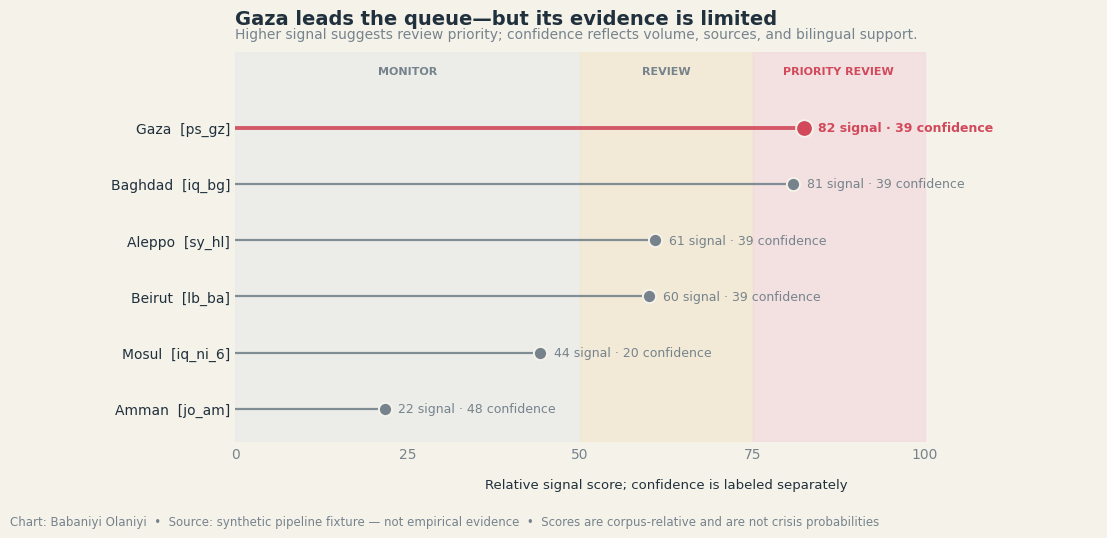

In [8]:
def build_geo_article_rows(articles_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in articles_df[articles_df.has_geo].iterrows():
        weight = 1.0 / len(row.geo_ids)
        for geo_id in row.geo_ids:
            rows.append(
                {
                    "geo_id": geo_id,
                    "article_id": row.article_id,
                    "language": row.language,
                    "source": row.source,
                    "weight": weight,
                    "has_risk": int(row.has_risk),
                    "risk_mentions": row.risk_mention_count,
                    "token_count": row.token_count,
                    "clusters": row.clusters,
                }
            )
    return pd.DataFrame(rows)


geo_articles = build_geo_article_rows(articles)


def location_index(geo_articles_df: pd.DataFrame, prior_strength: float = 20.0) -> pd.DataFrame:
    if geo_articles_df.empty:
        return pd.DataFrame()
    global_rate = np.average(geo_articles_df.has_risk, weights=geo_articles_df.weight)
    alpha0 = prior_strength * global_rate + 0.5
    beta0 = prior_strength * (1 - global_rate) + 0.5
    rows = []
    for geo_id, g in geo_articles_df.groupby("geo_id"):
        n = g.weight.sum()
        k = (g.weight * g.has_risk).sum()
        alpha, beta = alpha0 + k, beta0 + n - k
        cluster_set = {c for values in g.clusters for c in values}
        weighted_mentions = (g.weight * g.risk_mentions).sum()
        weighted_tokens = max((g.weight * g.token_count).sum(), 1)
        rows.append(
            {
                "geo_id": geo_id,
                "name_en": geo.loc[geo_id, "name_en"],
                "name_ar": geo.loc[geo_id, "name_ar"],
                "level": geo.loc[geo_id, "level"],
                "country_id": geo.loc[geo_id, "country_id"],
                "article_weight": n,
                "risk_article_weight": k,
                "raw_risk_share": k / n,
                "posterior_news_risk": alpha / (alpha + beta),
                "risk_ci_low": beta_dist.ppf(0.05, alpha, beta),
                "risk_ci_high": beta_dist.ppf(0.95, alpha, beta),
                "mentions_per_1000_tokens": 1000 * weighted_mentions / weighted_tokens,
                "cluster_breadth": len(cluster_set),
                "languages": g.language.nunique(),
                "sources": g.source.nunique(),
            }
        )
    out = pd.DataFrame(rows)
    rank_cols = ["posterior_news_risk", "mentions_per_1000_tokens", "cluster_breadth"]
    for col in rank_cols:
        out[col + "_pct"] = out[col].rank(pct=True, method="average")
    out["signal_score"] = 100 * (
        0.60 * out.posterior_news_risk_pct
        + 0.25 * out.mentions_per_1000_tokens_pct
        + 0.15 * out.cluster_breadth_pct
    )
    volume_reliability = out.article_weight / (out.article_weight + prior_strength)
    source_reliability = np.minimum(out.sources / 3, 1)
    bilingual = np.where(out.languages >= 2, 1.0, 0.5)
    out["evidence_confidence"] = 100 * (0.60 * volume_reliability + 0.20 * source_reliability + 0.20 * bilingual)
    out["triage"] = pd.cut(
        out.signal_score,
        bins=[-np.inf, 50, 75, np.inf],
        labels=["monitor", "review", "priority review"],
    ).astype(str)
    return out.sort_values(["signal_score", "evidence_confidence"], ascending=False).reset_index(drop=True)


location_scores = location_index(geo_articles, prior_strength=20)
if location_scores.empty:
    display(Markdown("No unambiguous geotags were available; no location index can be estimated."))
else:
    shown = ["geo_id", "name_en", "level", "article_weight", "languages", "sources", "cluster_breadth",
             "posterior_news_risk", "risk_ci_low", "risk_ci_high", "mentions_per_1000_tokens",
             "signal_score", "evidence_confidence", "triage"]
    display(location_scores[shown].round(3))

    top = location_scores.head(12).sort_values("signal_score")
    leader = location_scores.iloc[0]
    confidence_word = "limited" if leader.evidence_confidence < 50 else "stronger"
    fig, ax = plt.subplots(figsize=(12.5, max(6.2, 0.62 * len(top) + 2.3)), facecolor=VIZ_BG)
    fig.subplots_adjust(left=0.24, right=0.93, top=0.78, bottom=0.15)

    # Subtle decision zones give the score context without gridline clutter.
    ax.axvspan(0, 50, color="#E9ECE8", alpha=0.72, zorder=0)
    ax.axvspan(50, 75, color="#F1E8CE", alpha=0.70, zorder=0)
    ax.axvspan(75, 100, color="#F3DADD", alpha=0.72, zorder=0)
    ax.text(25, len(top) - 0.08, "MONITOR", ha="center", va="bottom", fontsize=8, color=VIZ_MUTED_DARK, fontweight="bold")
    ax.text(62.5, len(top) - 0.08, "REVIEW", ha="center", va="bottom", fontsize=8, color=VIZ_MUTED_DARK, fontweight="bold")
    ax.text(87.5, len(top) - 0.08, "PRIORITY REVIEW", ha="center", va="bottom", fontsize=8, color=VIZ_ACCENT, fontweight="bold")

    y = np.arange(len(top))
    for i, (_, row) in enumerate(top.iterrows()):
        is_leader = row.geo_id == leader.geo_id
        color = VIZ_ACCENT if is_leader else VIZ_MUTED_DARK
        ax.plot([0, row.signal_score], [i, i], color=color, lw=2.8 if is_leader else 1.6, alpha=0.9, zorder=2)
        ax.scatter(row.signal_score, i, s=145 if is_leader else 90, color=color,
                   edgecolor=VIZ_BG, linewidth=1.4, zorder=3)
        label_x = min(row.signal_score + 2.0, 101.5)
        ax.text(label_x, i, f"{row.signal_score:.0f} signal · {row.evidence_confidence:.0f} confidence",
                va="center", ha="left", fontsize=9, color=color,
                fontweight="bold" if is_leader else "normal")

    ax.set_yticks(y, top.name_en + "  " + top.geo_id.map(lambda value: f"[{value}]") )
    ax.set_xlim(0, 125)
    ax.set_ylim(-0.6, len(top) + 0.35)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xlabel("Relative signal score; confidence is labeled separately", labelpad=12, fontsize=9.5)
    ax.set_ylabel("")
    ax.set_title(f"{leader.name_en} leads the queue—but its evidence is {confidence_word}", loc="left", pad=20)
    ax.text(0, 1.035, "Higher signal suggests review priority; confidence reflects volume, sources, and bilingual support.",
            transform=ax.transAxes, fontsize=10, color=VIZ_MUTED_DARK)
    polish_axis(ax)
    add_caption(fig, f"Chart: Babaniyi Olaniyi  •  Source: {DATA_MODE.lower()}  •  Scores are corpus-relative and are not crisis probabilities")
    plt.show()

### Drill-down: evidence behind a flagged location

An alert without provenance is not useful. The table below links each top-ranked place to the specific article, language, source, clusters, and snippet that created the signal. An analyst can reject negated, historical, irrelevant, or duplicate claims before escalation.

In [9]:
def evidence_for_location(geo_id: str, limit: int = 8) -> pd.DataFrame:
    ids = set(geo_articles.loc[geo_articles.geo_id.eq(geo_id), "article_id"])
    cols = ["article_id", "date", "language", "source", "risk_factor_labels", "clusters", "snippet"]
    return articles.loc[articles.article_id.isin(ids) & articles.has_risk, cols].sort_values("date").head(limit)


if not location_scores.empty:
    top_geo_id = location_scores.iloc[0].geo_id
    display(Markdown(f"**Top queue item:** `{top_geo_id}` — {geo.loc[top_geo_id, 'name_en']}"))
    display(evidence_for_location(top_geo_id))

**Top queue item:** `ps_gz` — Gaza

,article_id,date,language,source,risk_factor_labels,clusters,snippet
10,e05,2025-01-10,en,synthetic_wire_b,"[acute hunger, blockade, bombing campaign, displaced]","[conflicts and violence, food crisis, forced displacement]","Displacement in Gaza. Displaced civilians in Gaza, Palestine, face acute hunger after ..."
3,a04,2025-01-11,ar,synthetic_ar_b,"[acute hunger, displaced, siege]","[conflicts and violence, food crisis, forced displacement]",جوع حاد بين النازحين في غزة. نازحون في غزة فلسطين يواجهون جوعا حادا بعد حصار عسكري وحم...


## 8. Robustness checks and failure tests

With no outcome labels, robustness is about measurement—not predictive accuracy. The prior-strength sweep tests whether sparse-location rankings are an artifact of a single smoothing choice. A production system should also report rankings after removing each major publisher, each language, and each keyword cluster; unstable alerts need review.

prior_b,5,10,20,50
prior_a,,,,
5,1.0,1.0,1.0,1.0
10,1.0,1.0,1.0,1.0
20,1.0,1.0,1.0,1.0
50,1.0,1.0,1.0,1.0


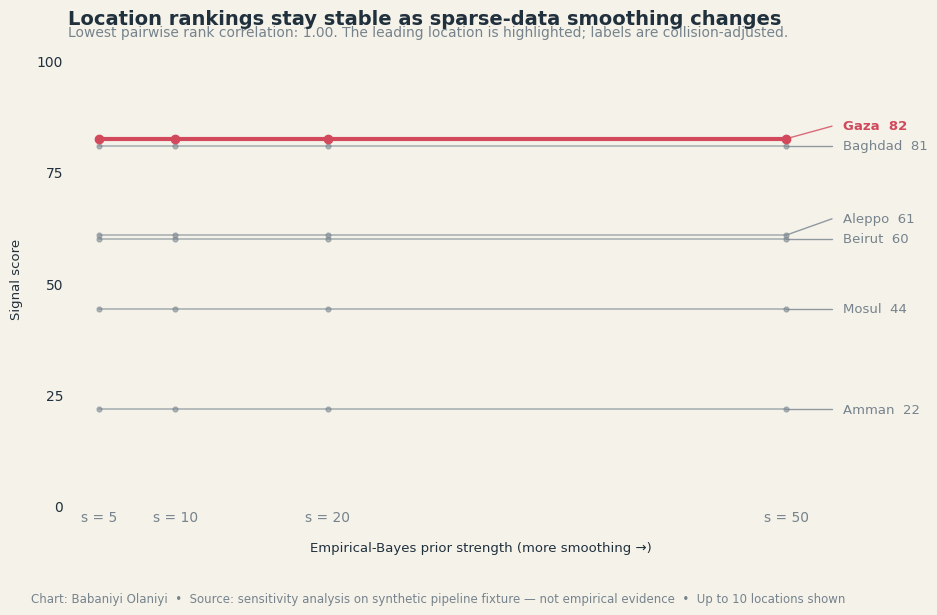

,test,passed
0,167 factors retained,True
1,all factors categorized,True
2,all factors have Arabic seed,True
3,risk lookup has all English keys,True
4,no empty standardized articles,True
5,location IDs valid,True
6,scores bounded,True


In [10]:
prior_grid = [5, 10, 20, 50]
sensitivity = []
score_versions = {}
for strength in prior_grid:
    scored = location_index(geo_articles, strength)
    if not scored.empty:
        score_versions[strength] = scored.set_index("geo_id")["signal_score"]

for a in prior_grid:
    for b in prior_grid:
        if a in score_versions and b in score_versions:
            common = score_versions[a].index.intersection(score_versions[b].index)
            rho = spearmanr(score_versions[a].loc[common], score_versions[b].loc[common]).statistic if len(common) > 1 else np.nan
            sensitivity.append({"prior_a": a, "prior_b": b, "spearman_rank_correlation": rho})

if sensitivity:
    sensitivity_df = pd.DataFrame(sensitivity)
    matrix = sensitivity_df.pivot(index="prior_a", columns="prior_b", values="spearman_rank_correlation")
    display(matrix.round(3))

    # Direct-labeled lines make individual rank stability more legible than a correlation heatmap.
    score_panel = pd.DataFrame(score_versions).sort_index(axis=1)
    selected_ids = [g for g in location_scores.head(10).geo_id if g in score_panel.index]
    score_panel = score_panel.loc[selected_ids]
    highlight_geo = selected_ids[0] if selected_ids else None
    end_values = score_panel.iloc[:, -1].tolist()
    label_y = spread_label_positions(end_values, minimum_gap=4.5, low=3, high=97)
    off_diagonal = matrix.to_numpy()[~np.eye(len(matrix), dtype=bool)] if len(matrix) > 1 else np.array([np.nan])
    min_rho = np.nanmin(off_diagonal) if np.isfinite(off_diagonal).any() else np.nan
    stable = np.isfinite(min_rho) and min_rho >= 0.90
    title = ("Location rankings stay stable as sparse-data smoothing changes"
             if stable else "Some location rankings depend on the smoothing assumption")

    fig, ax = plt.subplots(figsize=(12.5, 7.2), facecolor=VIZ_BG)
    fig.subplots_adjust(left=0.09, right=0.75, top=0.78, bottom=0.15)
    strengths = score_panel.columns.to_numpy(dtype=float)
    for index, (geo_id, row) in enumerate(score_panel.iterrows()):
        is_focus = geo_id == highlight_geo
        color = VIZ_ACCENT if is_focus else VIZ_MUTED_DARK
        ax.plot(strengths, row.values, color=color, lw=3.0 if is_focus else 1.35,
                alpha=1.0 if is_focus else 0.52, marker="o", ms=6 if is_focus else 3.5, zorder=3 if is_focus else 2)
        ending = float(row.iloc[-1])
        ax.plot([strengths[-1], strengths[-1] + 3.0], [ending, label_y[index]], color=color,
                lw=1.0, alpha=0.8, clip_on=False)
        location_name = geo.loc[geo_id, "name_en"] if geo_id in geo.index else geo_id
        ax.text(strengths[-1] + 3.7, label_y[index], f"{location_name}  {ending:.0f}", va="center",
                fontsize=9.5, color=color, fontweight="bold" if is_focus else "normal", clip_on=False)

    ax.set_xlim(strengths.min() - 2, strengths.max() + 7)
    ax.set_ylim(0, 102)
    ax.set_xticks(strengths, [f"s = {int(value)}" for value in strengths])
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_xlabel("Empirical-Bayes prior strength (more smoothing →)", labelpad=12, fontsize=9.5)
    ax.set_ylabel("Signal score", labelpad=10, fontsize=9.5)
    ax.set_title(title, loc="left", pad=20)
    subtitle = (f"Lowest pairwise rank correlation: {min_rho:.2f}. " if np.isfinite(min_rho) else "") +                "The leading location is highlighted; labels are collision-adjusted."
    ax.text(0, 1.035, subtitle, transform=ax.transAxes, fontsize=10, color=VIZ_MUTED_DARK)
    polish_axis(ax)
    add_caption(fig, f"Chart: Babaniyi Olaniyi  •  Source: sensitivity analysis on {DATA_MODE.lower()}  •  Up to 10 locations shown")
    plt.show()

# Contract tests make silent pipeline failure visible.
tests = {
    "167 factors retained": len(lexicon) == 167,
    "all factors categorized": lexicon.cluster.notna().all(),
    "all factors have Arabic seed": lexicon.risk_factor_arabic.notna().all(),
    "risk lookup has all English keys": set(lexicon.factor_key) == set(risk_lookup_en),
    "no empty standardized articles": articles.text_norm.ne("").all(),
    "location IDs valid": all(g in geo.index for ids in articles.geo_ids for g in ids),
    "scores bounded": location_scores.empty or location_scores.signal_score.between(0, 100).all(),
}
test_results = pd.DataFrame({"test": tests.keys(), "passed": tests.values()})
display(test_results)
assert test_results.passed.all(), test_results.loc[~test_results.passed, "test"].tolist()

## 9. From an index to a genuine forecast

### Labels and leakage-safe panel

The next dataset should have one row per district-month. The target is a policy-defined adverse transition, for example:

`y[g,t,h] = 1 if IPC/CH phase at g reaches ≥3 or worsens by ≥1 phase during t+1…t+h`.

Features available by the forecast cutoff include lagged IPC/CH phase and duration, lagged news signals by cluster/language/source, price anomalies, rainfall and vegetation anomalies, conflict/access events, displacement, seasonality, population, and neighboring-district lags. A publication-delay ledger is essential: a label or covariate belongs to its *release vintage*, not merely the period it describes.

### Model and evaluation

Start with interpretable baselines before a random forest or gradient boosting model:

1. prevalence-only baseline;
2. last observed phase / crisis-history baseline;
3. structured covariates only;
4. news only;
5. history + structured + news.

Use expanding-window evaluation (`train ≤ T`, validate `T+1…T+h`) with a final untouched time block. Add geographic holdouts to test transfer to thin-data districts. Compare models with area under the precision-recall curve, recall among the top `K` actionable alerts, Brier score/calibration curves, and subgroup metrics by country, language coverage, conflict history, and media volume. The key incremental estimand is **(history + structured + news) minus (history + structured)** on identical future folds.

Rare-event class weights can improve ranking but do not fix calibration; probabilities should be recalibrated on a later validation window. Random row splits, SMOTE before a time split, and contemporaneous labels would all leak information.

### Weak supervision without pretending it is truth

Where labels are sparse, combine multiple noisy labeling functions—IPC/CH reports, humanitarian appeals, price/rainfall extremes, displacement, and expert-coded alerts—in a latent-label model, then keep a small expert adjudication set for evaluation. Positive-unlabeled learning is appropriate when observed crises are reliable positives but missing labels are not reliable negatives. Active learning should send uncertain/diverse cases to reviewers. None of these synthetic labels should be reported as ground truth.

## 10. Decision threshold: prediction is not the policy

Mueller & Rauh emphasize that a low base rate makes the prevention problem “hard” and that the useful threshold depends on policy effectiveness and costs. If a calibrated forecast gives risk `q`, an intervention costs `I`, prevents the bad outcome with probability `e`, and avoids damage `D−P`, intervene when:


$q > \frac{I}{e(D-P)} $

The table below makes the implication concrete. It is a scenario analysis—not an empirical recommendation. Less effective or more expensive interventions require much higher forecast risk. If the ratio exceeds 1, that intervention is not cost-effective under the assumptions even at certainty. Different actions (desk review, phone verification, pre-positioning aid, cash transfer) should have different thresholds.

In [11]:
scenarios = []
for effectiveness in [0.05, 0.10, 0.25, 0.50]:
    for intervention_cost_share in [0.01, 0.05, 0.10]:
        threshold = intervention_cost_share / effectiveness
        scenarios.append(
            {
                "intervention_effectiveness": effectiveness,
                "I / (D-P)": intervention_cost_share,
                "required_calibrated_risk": threshold,
                "feasible_under_assumptions": threshold <= 1,
            }
        )
decision_table = pd.DataFrame(scenarios)
display(decision_table.style.format({"intervention_effectiveness": "{:.0%}", "I / (D-P)": "{:.0%}",
                                     "required_calibrated_risk": "{:.0%}"}))

,intervention_effectiveness,I / (D-P),required_calibrated_risk,feasible_under_assumptions
0,5%,1%,20%,True
1,5%,5%,100%,True
2,5%,10%,200%,False
3,10%,1%,10%,True
4,10%,5%,50%,True
5,10%,10%,100%,True
6,25%,1%,4%,True
7,25%,5%,20%,True
8,25%,10%,40%,True
9,50%,1%,2%,True


## 11. Operational design and proposed additional data

### Daily-to-monthly system

1. ingest and fingerprint articles; retain source and retrieval timestamp;
2. language identification, normalization, exact/near-duplicate clustering;
3. multilingual risk retrieval plus assertion/negation and affected-population checks;
4. hierarchical geoparsing with confidence and human-auditable spans;
5. aggregate features to district-month using publication cutoffs;
6. join versioned structured covariates;
7. score with a frozen model, monitor drift/coverage, and produce a ranked verification queue;
8. record reviewer decisions and eventual outcomes for learning and audit.

### High-value open data

| Need | Candidate source | Feature |
|---|---|---|
| Outcome | IPC / Cadre Harmonisé, FEWS NET | phase, change, projection horizon |
| Rainfall | CHIRPS | standardized rainfall anomaly, dry-spell duration |
| Vegetation | MODIS/VIIRS | NDVI anomaly relative to local season |
| Prices | WFP VAM / national market data | staple-price level and month-on-month anomaly |
| Conflict/access | UCDP GED or ACLED; OCHA access constraints | event/fatality/access lags and distance |
| Exposure | WorldPop / displacement data | population at risk, arrivals/departures |

These covariates make the spatial tag useful: observations can be harmonized to stable administrative boundaries and enriched with own-area and neighbor lags. Boundary-version crosswalks and uncertainty must be retained.

### Monitoring

Track input volume by source/language/location, unseen tokens and place aliases, risk-hit rate, duplicates, unparseable dates, geotag coverage, score distribution, and delayed calibration. Trigger investigation on source outages, abrupt language imbalance, or ranking instability. Publish a model card and keep article-level provenance; sensitive alerts should be access-controlled because location-level predictions can stigmatize communities or create security risks.

## 12. Conclusions

The strongest defensible output from the supplied snapshot is an **auditable bilingual screening and measurement pipeline**. It uses geographic detail to make signals actionable, but explicitly separates signal from evidence confidence. It also resists a common failure in data-scarce work: fitting a sophisticated classifier to labels that do not exist and presenting the result as prediction.

When the actual CSVs are present, the tables and plots above will reveal coverage, retrieved themes, cross-language asymmetries, sparse-location uncertainty, and the article provenance behind each location. The empirical claim to test later is narrow and falsifiable: *does lagged bilingual news improve future, geographically held-out IPC/CH ranking and calibration beyond crisis history and structured early-warning covariates?*

## Part 2 — Reflection

### Limitations

- **Missing news inputs in this copy.** Current outputs use a synthetic pipeline fixture and are not substantive findings.
- **No ground truth and only one month.** The index is not a forecast, cannot establish lead time, and cannot be evaluated out of time.
- **Dictionary validity.** The Arabic list is a seed translation without native-speaker adjudication or dialectal expansion. Exact matching misses paraphrases and captures negated/historical statements.
- **Source and language selection.** Article supply differs across outlets, countries, languages, and conflict intensity. Bilingual agreement can reflect shared syndication rather than independent confirmation.
- **Geoparsing.** Gazetteer matches confuse mention with affected location, omit implicit geography, and discard unresolved aliases. No coordinates/boundaries means no map or adjacency features.
- **Deduplication.** Exact hashes do not remove lightly edited wire copies.
- **Composite score choices.** Weights and the beta prior are explicit but judgmental. Percentile scores are sample-relative and incomparable across vintages unless frozen.
- **Ethics and actionability.** False alarms consume scarce attention; missed crises cause harm. Localized flags may expose or stigmatize communities.

### What I would do with more time

1. obtain the missing CSVs, profile their source/date coverage, annotate a stratified bilingual retrieval set, and revise the lexicon with two native reviewers;
2. add multilingual semantic retrieval only after measuring its incremental precision/recall over this exact-match baseline, plus an assertion/negation classifier;
3. implement near-duplicate/source-family clustering and model independent corroboration rather than raw article volume;
4. add administrative boundaries, historical crosswalks, coordinate-based geoparsing, adjacency, and spatial uncertainty;
5. build a vintage-correct district-month panel with IPC/CH, CHIRPS, NDVI, market prices, displacement, conflict, access, seasonality, population, and crisis history;
6. compare nested baselines in expanding-window and geographic holdout tests, calibrate on later data, and report top-`K` recall plus policy cost curves;
7. run retrospective analyst review, prospective shadow deployment, drift monitoring, and documented escalation/redress procedures before any operational use.

## References

- Mueller, H. & Rauh, C. (2020), [*The Hard Problem of Prediction for Conflict Prevention*](https://bse.eu/sites/default/files/working_paper_pdfs/1244.pdf). Applied here through rare-event framing, history/text complementarity, sequential testing, and cost-sensitive intervention thresholds.
- Balashankar, A., Subramanian, L. & Fraiberger, S. P. (2023), [*Predicting food crises using news streams*](https://doi.org/10.1126/sciadv.abm3449), *Science Advances* 9(9), eabm3449.
- [Replication code for predicting food crises using news streams](https://github.com/philippzi98/food_insecurity_predictions_nlp).
- [IPC classification](https://www.ipcinfo.org/ipcinfo-website/ipc-overview-and-classification-system/en/) and [FEWS NET](https://fews.net/) for food-security outcomes.
- [CHIRPS](https://www.chc.ucsb.edu/data/chirps) for rainfall and [WFP VAM](https://dataviz.vam.wfp.org/) for food-security/market indicators.

---

### Reproducibility

- Python 3.11; core dependencies: pandas, numpy, scipy, matplotlib, seaborn, openpyxl, nbformat.
- Fixed random seed: 42.
- No network calls, secrets, or runtime translation APIs.
- To run: place the two news CSVs in `data/`, select the project kernel, and **Restart Kernel and Run All**.
- All current cells were executed top-to-bottom and outputs are saved in this notebook.